<h1>ENSO Index - Ensemble Means</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 sst data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/sst/'

In [4]:
ufs_vars_list = ['tmpsfc', 'tsfc']
era5_var = 'sea_surface_temperature'
seas5_var = 'sst'

In [5]:
ufs_experiments = ['baseline', 'beta.0.1', 'c96_beta.0.1', 'cpc_ics']

In [6]:
# Collect all sst seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [7]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [8]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [9]:
# Get ERA5 data
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [10]:
# seas5_data_reader.describe(seas5_var)

<h5>Define time period</h5>

In [11]:
time_range = ("1994-02-01","2021-12-31T23")
initmonths = (5,)

<h5>Define nino 3.4 region</h5>

In [12]:
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax':240.0
}

<h5>Get the monthly climatology for nino 3.4</h5>

In [13]:
%%capture captured_output
# First, collect all the ensemble means for the UFS models.
ufs_ds = util.combine_ufs_means(ufs_experiments, ufs_vars_list, time_range, region=region, initmonths=initmonths)

<h5>Get the corresponding ERA5 data</h5>

In [14]:
era5_ds = era5_data_reader.retrieve(var=era5_var,
                                    lat=(region['latmin'], region['latmax']),
                                    lon=(region['lonmin'], region['lonmax']),
                                    time=time_range)

In [15]:
seas5_ds = seas5_data_reader.retrieve(var=seas5_var,
                                      lat=(region['latmin'], region['latmax']),
                                      lon=(region['lonmin'], region['lonmax']),
                                      initmonths=initmonths,
                                      time=time_range,
                                      ens_avg=True)

Taking Ensemble Average


In [19]:
# Because both the seas5 and ufs models have init+lead structure,
# combine seas5 into the ufs dataset as a standalone "member"

# Rename to match ufs
seas5_ds = seas5_ds.rename({'sst': 'tmpsfc'})
# consider ecmwf a 'member'
seas5_ds = seas5_ds.assign_coords(member=('member', ['seas5']))
# Concatenate with ufs
ufs_ds = xr.concat([ufs_ds, seas5_ds], dim='member', coords='minimal', compat='equals')

<h5>Calculate climatology (this may take a couple minutes)</h5>

In [20]:
ufs_stats = stats.calc_climatology_anomaly(ufs_ds, area_mean=True, use_member_climatology=True)

In [21]:
era5_stats = stats.calc_climatology_anomaly(era5_ds, area_mean=True, use_member_climatology=True)

Generating 4 panel(s).
Processing years 1994 to 1999
Processing years 2000 to 2009
Processing years 2010 to 2019
Processing years 2020 to 2021


<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

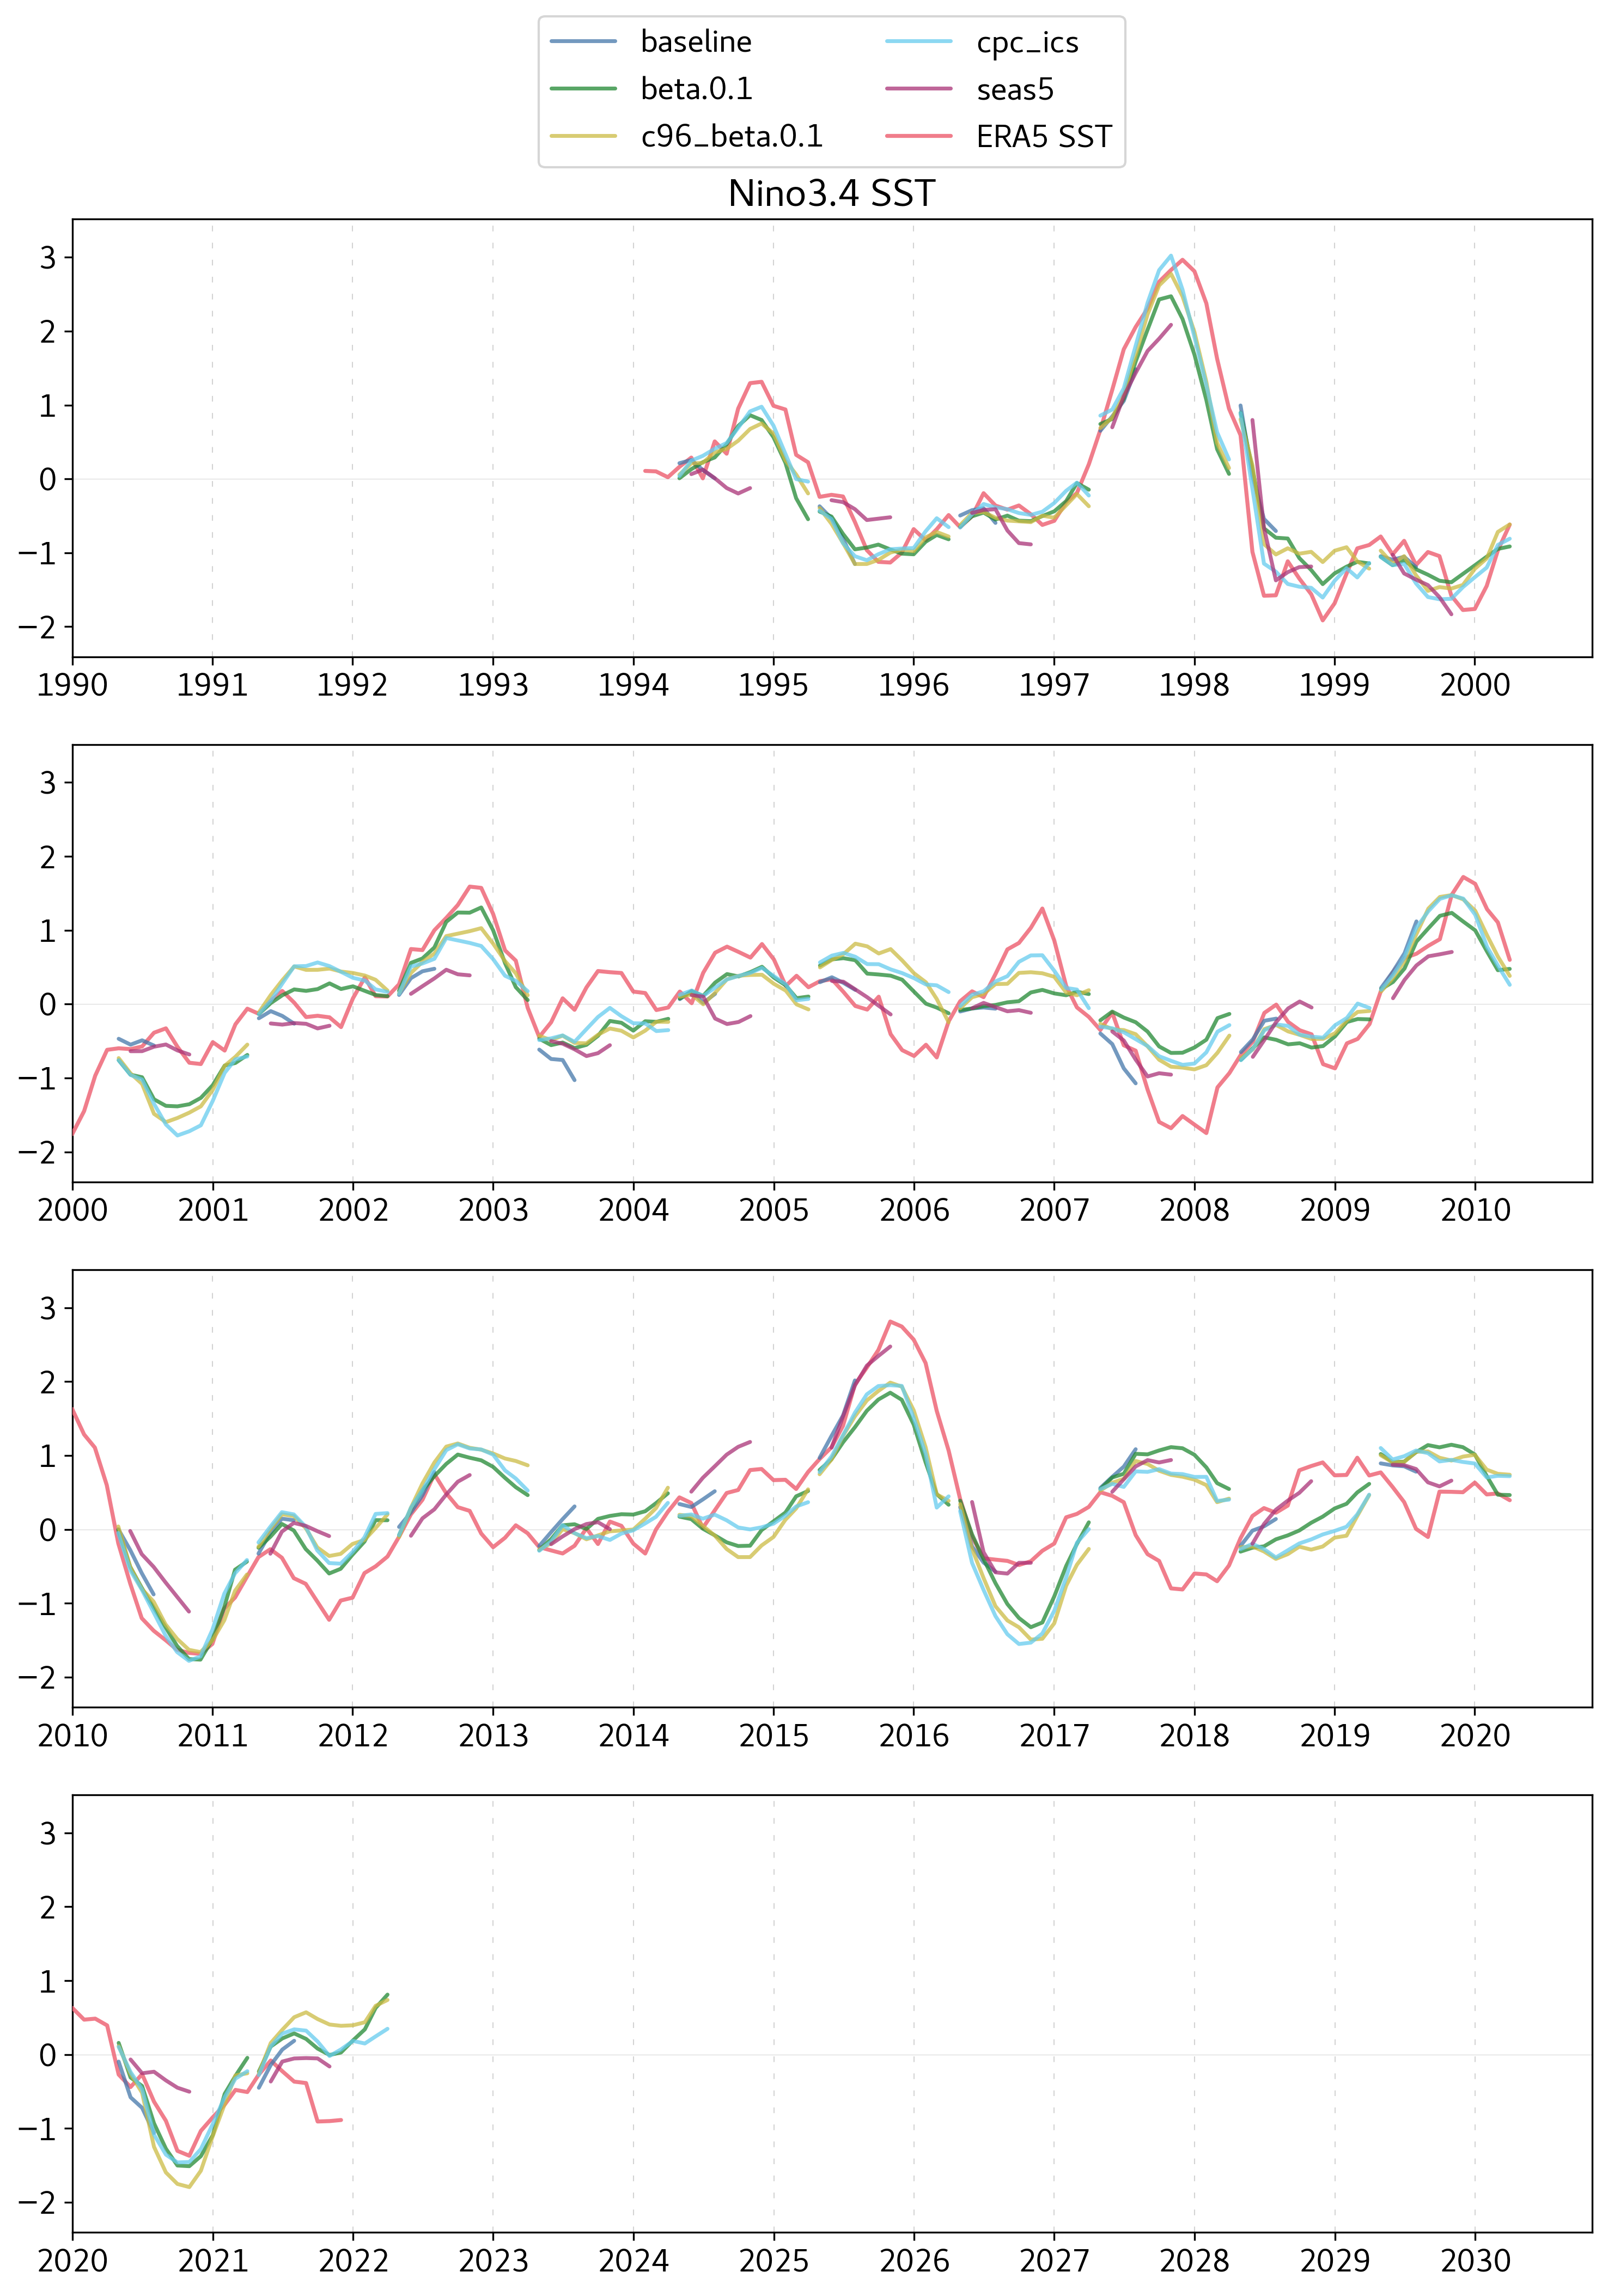

In [22]:
stats.plot_index_spaghetti(ufs_stats=ufs_stats,
                           verif_stats=era5_stats,
                           calc_anomaly=True,
                           title=f'Nino3.4 SST',
                           verif_label='ERA5 SST',
                           dpi=300)